# Credit Risk Modeling — Home Credit Default Risk

## Overview

This notebook builds and compares **supervised classification models** to predict whether a loan applicant will default, using the Home Credit Default Risk dataset (307,511 loan applications, 122 columns).

It is the **predictive modeling companion** to the exploratory analysis in `credit-risk-analysis.ipynb`, where I identified the segments and behaviors associated with higher default risk using SQL and Python. Here the goal is to turn those patterns into a quantitative scoring model and to evaluate it rigorously.

## Business Problem

A financial institution wants to anticipate which applicants are most likely to default, in order to:

- Support credit approval decisions with a risk score
- Adjust loan terms according to risk profile
- Focus review resources on the riskiest applications

## Key Challenge: Class Imbalance

Only **8.07%** of clients default (91.9% vs 8.1%). A model that predicts "nobody defaults" would be 92% accurate and completely useless. For this reason, models are evaluated with **ROC-AUC** and with **recall and precision on the default class**, never with accuracy alone.

## Notebook Structure

1. Setup and data loading
2. Feature selection and stratified train/test split
3. Logistic Regression and Random Forest
4. Gradient Boosting and ROC curves
5. Feature importance (permutation importance)
6. Conclusions, limitations and next steps

**Dataset:** [Home Credit Default Risk (Kaggle)](https://www.kaggle.com/competitions/home-credit-default-risk) — `application_train.csv`

## 1. Setup and Data Loading

Libraries and the `application_train.csv` file are loaded. As a sanity check, the shape and the default rate are printed. The expected output is **307,511 rows × 122 columns** and a default rate of **≈ 8.07%**, which confirms that the correct file was loaded and that the target is highly imbalanced.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, recall_score, precision_score, roc_curve

df = pd.read_csv('data/application_train.csv')
print(df.shape, df['TARGET'].mean())   # expected: (307511, 122) and ~0.0807

(307511, 122) 0.08072881945686496


## 2. Feature Selection and Stratified Split

**Features.** For this first version, only the **numeric columns** are used (the identifier `SK_ID_CURR` and the target `TARGET` are excluded). Categorical variables and the auxiliary tables (`bureau`, `previous_application`, ...) are left as future improvements.

**Split.** The data is divided into 80% training (246,008 clients) and 20% test (61,503 clients) with `stratify=y`. Stratification preserves the 92/8 class proportion in both sets, which is essential with imbalanced data, so the test set contains enough defaults to evaluate the models reliably.

In [2]:
X = df.select_dtypes(include='number').drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

# Stratified split: keeps the 92/8 class proportion in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features: {X.shape[1]}")
print(f"Train: {X_train.shape[0]} clients | Test: {X_test.shape[0]} clients")
print(f"Default rate - train: {y_train.mean():.4f} | test: {y_test.mean():.4f}")

Features: 104
Train: 246008 clients | Test: 61503 clients
Default rate - train: 0.0807 | test: 0.0807


## 3. Logistic Regression and Random Forest

Two models are trained as a baseline and a first ensemble method:

| Model | Preprocessing | Imbalance handling |
|---|---|---|
| Logistic Regression | Median imputation + standard scaling | `class_weight='balanced'` |
| Random Forest (200 trees) | Median imputation | `class_weight='balanced_subsample'` |

Imputation and scaling are placed **inside a pipeline**, so they are learned only from the training data. This prevents information from the test set from leaking into the preprocessing.

`class_weight` makes the models penalize a missed default more than a missed good client. Each model is evaluated on the test set with:

- **ROC-AUC:** how well the model ranks risky clients above safe ones, independent of the decision threshold
- **Recall (default):** share of real defaults the model detects
- **Precision (default):** share of flagged clients that really default

In [1]:
models = {
    "Logistic Regression": make_pipeline(
        SimpleImputer(strategy='median'), StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight='balanced')),
    "Random Forest": make_pipeline(
        SimpleImputer(strategy='median'),
        RandomForestClassifier(n_estimators=200, min_samples_leaf=50,
                               class_weight='balanced_subsample',
                               n_jobs=-1, random_state=42)),
}

for name, m in models.items():
    m.fit(X_train, y_train)
    proba = m.predict_proba(X_test)[:, 1]
    pred = m.predict(X_test)
    print(f"{name:20} AUC: {roc_auc_score(y_test, proba):.3f} | "
          f"Recall default: {recall_score(y_test, pred):.2f} | "
          f"Precision default: {precision_score(y_test, pred):.2f}")

NameError: name 'make_pipeline' is not defined

**Results**

| Model | AUC | Recall (default) | Precision (default) |
|---|---|---|---|
| Logistic Regression | 0.738 | 0.67 | 0.16 |
| Random Forest | 0.741 | 0.51 | 0.19 |

Both models reach practically the same AUC. The differences in recall and precision come mostly from the decision threshold, not from one model being better. A precision of 0.16 may look low, but the base default rate is 8%, so **flagged clients default about twice as often as the average client**.

## 4. Gradient Boosting and ROC Curves

A **histogram-based Gradient Boosting** model (`HistGradientBoostingClassifier`, with balanced class weights) is added. It handles missing values natively and can capture non-linear relationships and interactions between variables.

The ROC curve plots, for every possible decision threshold, the share of defaults detected (true positive rate) against the share of good clients wrongly flagged as risky (false positive rate). The closer a curve is to the top-left corner, the better the model separates both groups; the dashed diagonal represents random guessing (AUC = 0.5).

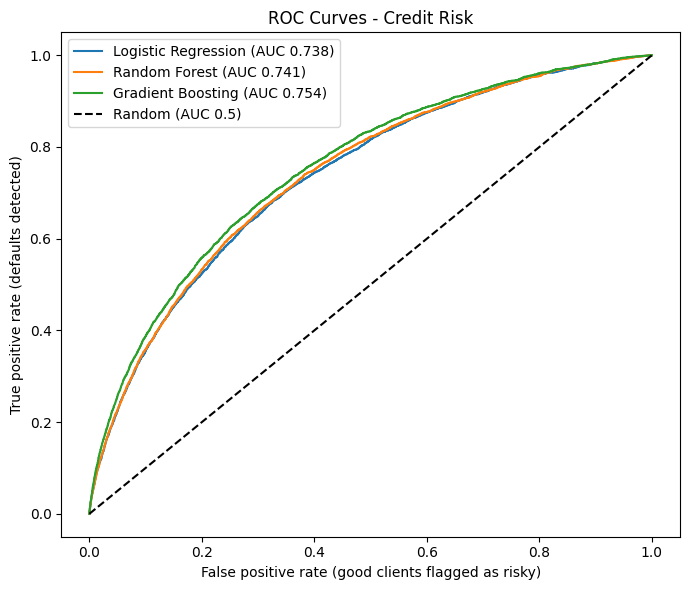

In [4]:
models["Gradient Boosting"] = HistGradientBoostingClassifier(
    class_weight='balanced', random_state=42)
models["Gradient Boosting"].fit(X_train, y_train)

plt.figure(figsize=(7, 6))
for name, m in models.items():
    proba = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC 0.5)')
plt.xlabel('False positive rate (good clients flagged as risky)')
plt.ylabel('True positive rate (defaults detected)')
plt.title('ROC Curves - Credit Risk')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

**Results**

| Model | AUC |
|---|---|
| Logistic Regression | 0.738 |
| Random Forest | 0.741 |
| **Gradient Boosting** | **0.754** |

Gradient Boosting performs slightly better, but the three curves are close. The improvement is real yet modest, which suggests that most of the signal is already captured by a simple model on these features.

## 5. Feature Importance

To understand what drives the best model, **permutation importance** is used: each variable is randomly shuffled and the drop in AUC is measured. The larger the drop, the more the model relies on that variable. It is computed on a random sample of 10,000 test clients with 5 repetitions.

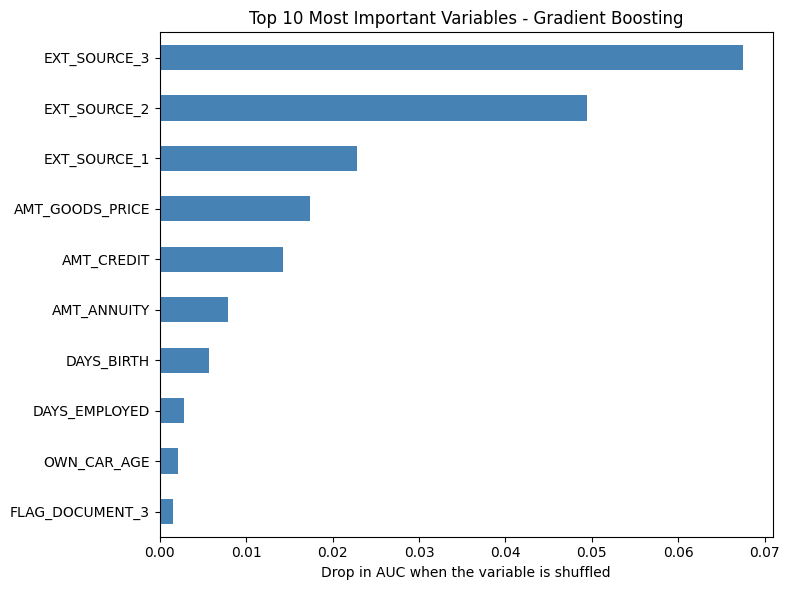

EXT_SOURCE_3       0.067519
EXT_SOURCE_2       0.049467
EXT_SOURCE_1       0.022876
AMT_GOODS_PRICE    0.017334
AMT_CREDIT         0.014245
AMT_ANNUITY        0.007956
DAYS_BIRTH         0.005671
DAYS_EMPLOYED      0.002779
OWN_CAR_AGE        0.002098
FLAG_DOCUMENT_3    0.001513
dtype: float64


In [5]:
gb = models["Gradient Boosting"]
sample = X_test.sample(10000, random_state=42)
y_sample = y_test.loc[sample.index]

r = permutation_importance(gb, sample, y_sample, scoring='roc_auc',
                           n_repeats=5, random_state=42, n_jobs=-1)

imp = pd.Series(r.importances_mean, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
imp.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Drop in AUC when the variable is shuffled')
plt.title('Top 10 Most Important Variables - Gradient Boosting')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print(imp)

**What the model relies on:**

- **`EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`** dominate. These are normalized scores from external sources of credit information, comparable to bureau scores. `EXT_SOURCE_3` alone causes the largest drop in AUC (≈ 0.07).
- **`AMT_GOODS_PRICE`, `AMT_CREDIT`, `AMT_ANNUITY`** come next. They describe the loan amount and its repayment burden, consistent with the exploratory finding that low-income clients devote a larger share of income to installments. `AMT_GOODS_PRICE` and `AMT_CREDIT` are highly correlated, so their importance is shared between them.
- **`DAYS_BIRTH`** (age) and **`DAYS_EMPLOYED`** contribute little.

The next cell checks how many clients are missing each external score, since the model loses its strongest signal when they are absent.

In [6]:
print((df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].isna().mean() * 100).round(1).astype(str) + '% missing')

EXT_SOURCE_1    56.4% missing
EXT_SOURCE_2     0.2% missing
EXT_SOURCE_3    19.8% missing
dtype: str


## 6. Conclusions, Limitations and Next Steps

### Conclusions

- The three models reach a ROC-AUC between **0.738 and 0.754**, with Gradient Boosting performing best. A model built only on numeric application data can already separate risky from safe clients far better than chance.
- Clients flagged by the model default about **twice as often** as the average client (precision 0.16 vs an 8% base rate), and Logistic Regression detects **67%** of real defaults at the default threshold.
- Predictive power relies mostly on **external scores** and on **loan amount and installment variables**.

### Business implications

- The decision threshold should be chosen according to the relative cost of approving a client who defaults versus rejecting a good one.
- Clients without external scores (missing values) lose the strongest signal, so they may need a specific review policy.
- Age should be handled carefully: it is a sensitive variable in credit scoring and its use may be restricted by regulation. Here its contribution is small.

### Limitations

- Single train/test split, no cross-validation or hyperparameter tuning
- Only numeric variables; categorical variables are not used
- Auxiliary tables (credit bureau, previous applications, payment history) are not used

### Next steps

- Add categorical variables and engineered features (for example, installment-to-income ratio)
- Aggregate information from `bureau.csv` and `previous_application.csv`
- Tune hyperparameters with cross-validation and calibrate the predicted probabilities
- Choose the decision threshold based on a cost-benefit analysis